In [ ]:
!pip install opencv-python matplotlib

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


(np.float64(-0.5), np.float64(259.5), np.float64(192.5), np.float64(-0.5))

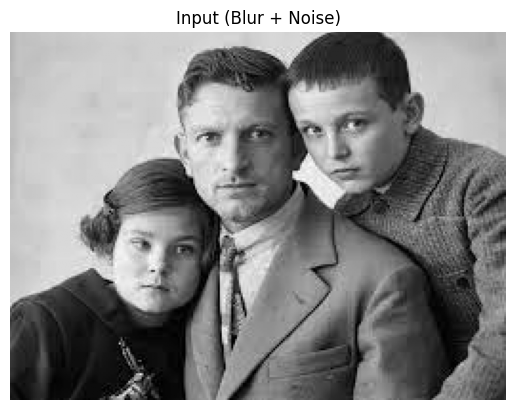

In [ ]:
img = cv2.imread("Enhancement.jpg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Image not found")

plt.imshow(img, cmap='gray')
plt.title("Input (Blur + Noise)")
plt.axis("off")


(np.float64(-0.5), np.float64(259.5), np.float64(192.5), np.float64(-0.5))

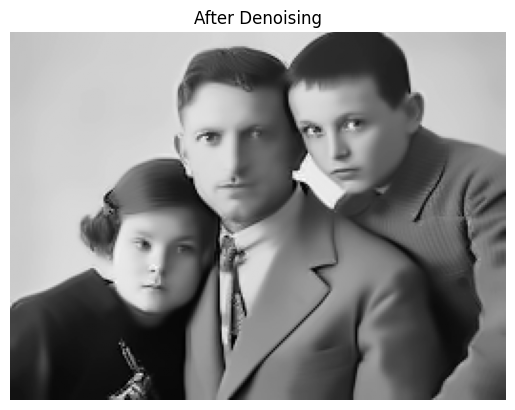

In [ ]:
denoised = cv2.fastNlMeansDenoising(
    img,
    None,
    h=15,        # noise strength
    templateWindowSize=7,
    searchWindowSize=21
)

plt.imshow(denoised, cmap='gray')
plt.title("After Denoising")
plt.axis("off")


(np.float64(-0.5), np.float64(259.5), np.float64(192.5), np.float64(-0.5))

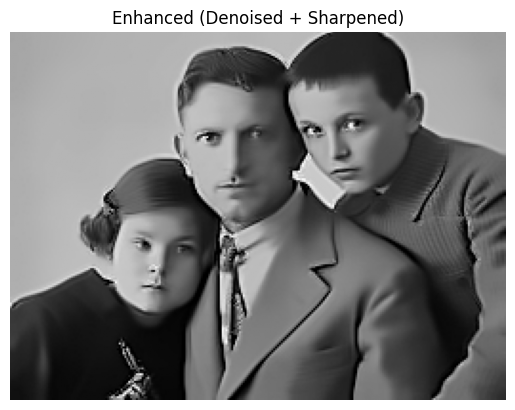

In [ ]:
blur = cv2.GaussianBlur(denoised, (0,0), sigmaX=1.5)
sharpened = cv2.addWeighted(
    denoised, 1.8,
    blur, -0.8,
    0
)

plt.imshow(sharpened, cmap='gray')
plt.title("Enhanced (Denoised + Sharpened)")
plt.axis("off")


(np.float64(-0.5), np.float64(259.5), np.float64(192.5), np.float64(-0.5))

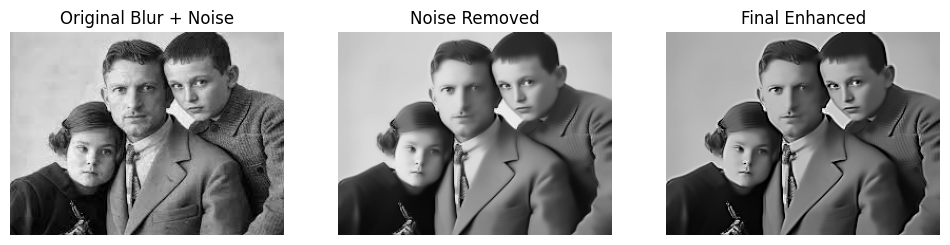

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Blur + Noise")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(denoised, cmap='gray')
plt.title("Noise Removed")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sharpened, cmap='gray')
plt.title("Final Enhanced")
plt.axis("off")


In [ ]:
cv2.imwrite("enhanced_output.jpg", sharpened)
print("✅ Enhanced image saved")